In [ ]:
# Benchmarking large-scale integration

In [2]:
!pip install scvi-tools

In [3]:
!pip install scib-metrics

In [4]:
import numpy as np
import scanpy as sc
from scvi.data import cellxgene

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

%matplotlib inline

In [5]:
# Saving an AnnData object
adata= sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/integration/Scvi/integrated_scVI.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 80193 × 3000
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    varm: 'PCs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [7]:
# We subset to the highly variable genes so that each method has the same input.
adata = adata[:, adata.var.highly_variable].copy()

In [ ]:
# This line filters the AnnData object to include only highly variable genes (HVGs).
# Most integration and downstream analyses (e.g., PCA, clustering, UMAP) 
# are performed only on HVGs because they carry more biological signal and reduce noise.
#.copy() creates a copy to avoid modifying the original adata by reference.

In [8]:
# This creates a new key in the obsm dictionary of the AnnData object called "Unintegrated".
# It stores a copy of the PCA representation (X_pca) under that new key.

# Why it's useful:
    #"Unintegrated" is often used as a label for the original, uncorrected embedding, especially in benchmarking workflows.
# It allows you to compare the pre-integration PCA (which may reflect batch effects) with post-integration embeddings (like X_scVI), which are supposed to be batch-corrected.
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

In [9]:
adata

AnnData object with n_obs × n_vars = 80193 × 3000
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'Unintegrated'
    varm: 'PCs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [15]:
# For a beautified visualization you can change the matplotlib settings
scv.set_figure_params()

In [29]:
import scanpy as sc

# Use the 'Unintegrated' PCA as the basis for UMAP
sc.pp.neighbors(adata, use_rep="Unintegrated")
sc.tl.umap(adata)
# save UMAP separately so it's not overwritten later
adata.obsm["X_umap_unintegrated"] = adata.obsm["X_umap"].copy()

In [31]:
print(adata.obs.columns)

Index(['Sample', 'n_genes', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels',
       'leiden', '_scvi_raw_norm_scaling'],
      dtype='object')


In [ ]:
scv.pl.umap

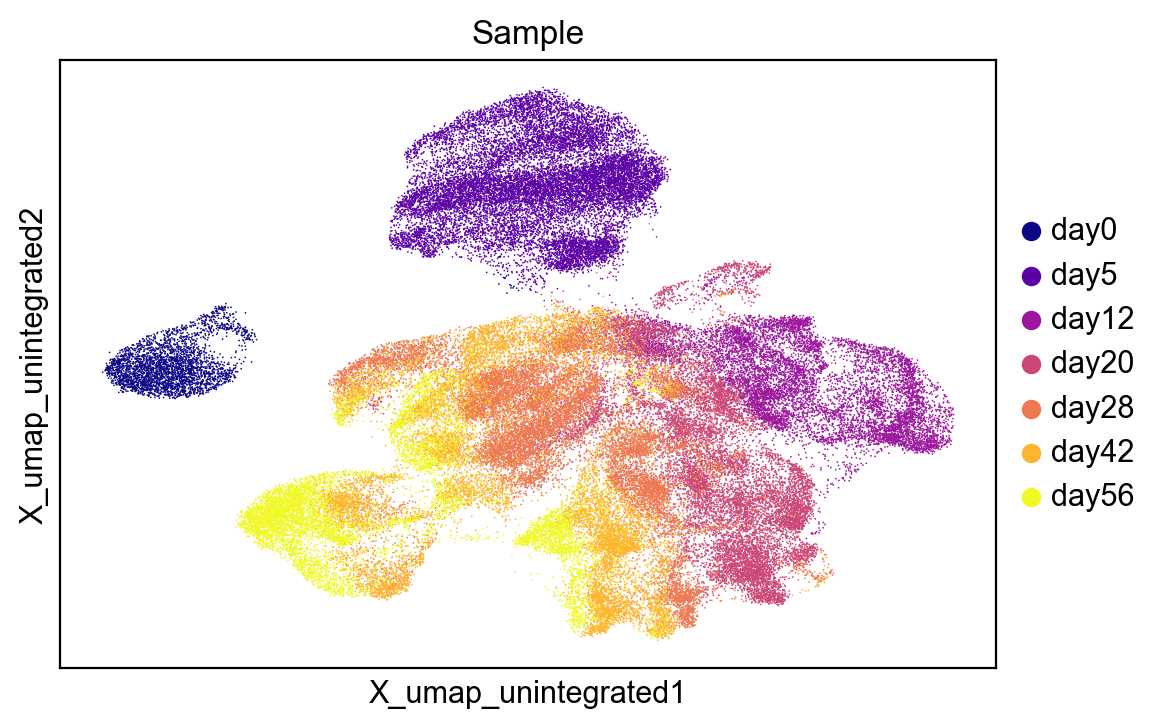

In [47]:
sc.pl.embedding(adata, basis="X_umap_unintegrated", color="Sample")  # or "leiden", "_scvi_batch", etc.

In [ ]:
# the code below is using scvelo graphics to plot umaps

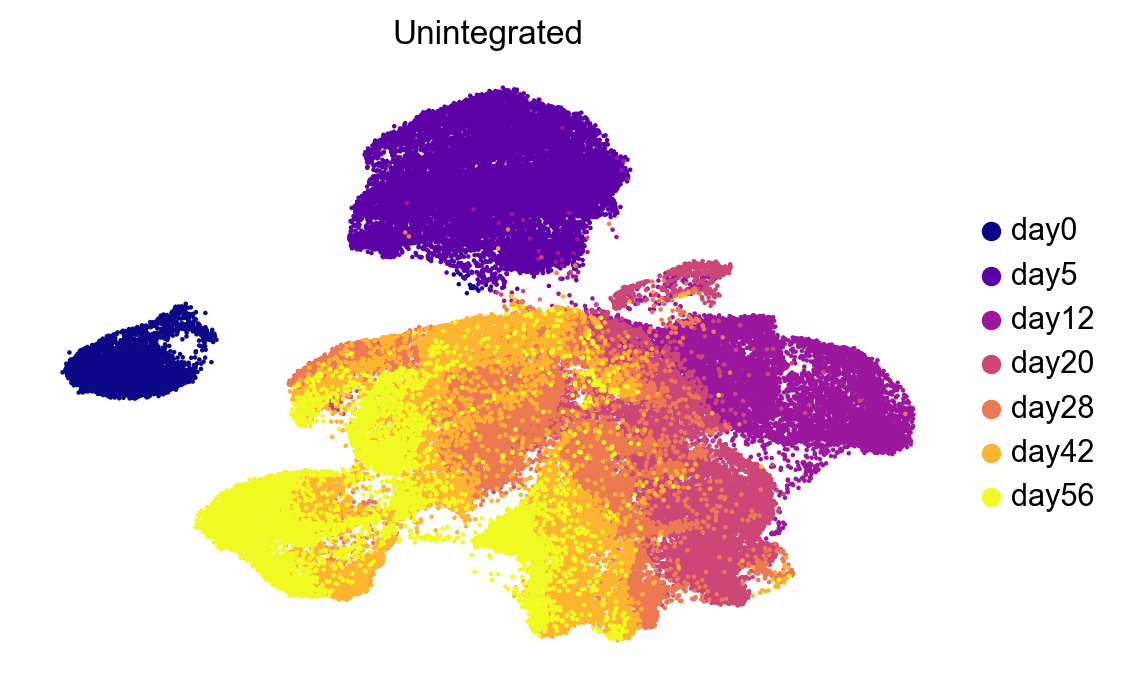

In [56]:
import scvelo as scv

# Backup original UMAP embedding
adata.obsm["_X_umap_backup"] = adata.obsm["X_umap"].copy()

# Replace X_umap with unintegrated UMAP
adata.obsm["X_umap"] = adata.obsm["X_umap_unintegrated"]

# Plot using scvelo with figsize 4x4
scv.pl.umap(
    adata, 
    color=["Sample"], 
    wspace=0.1, 
    title="Unintegrated", 
    legend_loc="right margin", 
    palette="plasma", 
    figsize=(6, 4)
)

# Restore original UMAP embedding
adata.obsm["X_umap"] = adata.obsm["_X_umap_backup"]
del adata.obsm["_X_umap_backup"]

In [57]:
adata

AnnData object with n_obs × n_vars = 80193 × 3000
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'Unintegrated', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [59]:
!pip install scanorama

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'intervaltree' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'intervaltree'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26190 sha256=de42c3313a39b1814f1bd1e65364ae2e9e8088a9f7517f1795cd2090cb5d063b
  Stored in directory: /Users/ogjaime/Library/Caches/pip/wheels/65/c3/c3/238bf93c243597857edd94ddb0577faa74a8e16e9585896e83
Successfully built intervaltree
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scanorama]


In [60]:
import scanorama

In [61]:
# check adata if batch exists
print(adata.obs.columns)

Index(['Sample', 'n_genes', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels',
       'leiden', '_scvi_raw_norm_scaling'],
      dtype='object')


In [62]:
# Use 'Sample' as the batch column
adata.obs["batch"] = adata.obs["Sample"].astype("category")

In [63]:
# quick sanity check
print(adata.obs["batch"].value_counts())

batch
day5     16188
day28    15839
day20    13261
day42    13051
day12     9937
day56     8573
day0      3344
Name: count, dtype: int64


In [64]:
#import scanorama
import numpy as np

# Split AnnData into list per batch
batch_cats = adata.obs["batch"].cat.categories
adata_list = [adata[adata.obs["batch"] == b].copy() for b in batch_cats]

# Integrate using Scanorama
scanorama.integrate_scanpy(adata_list)

# Assemble integrated embedding into the original AnnData
adata.obsm["Scanorama"] = np.zeros((adata.shape[0], adata_list[0].obsm["X_scanorama"].shape[1]))
for i, b in enumerate(batch_cats):
    adata.obsm["Scanorama"][adata.obs["batch"] == b] = adata_list[i].obsm["X_scanorama"]

Found 3000 genes among all datasets
[[0.00000000e+00 1.05861244e-01 7.74521531e-02 6.87799043e-03
  2.09330144e-02 2.99043062e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.30451847e-01 1.42698295e-02
  1.38374104e-02 5.37435137e-03 5.83226408e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.51202576e-01
  1.16534165e-01 2.51584985e-02 4.43252070e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  5.57169013e-01 1.01953096e-01 1.15478829e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 6.09455214e-01 1.16295346e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 7.22850811e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]]
Processing datasets (5, 6)
Processing datasets (2, 3)
Processing datasets (4, 5)
Processing datasets (3, 4)
Processing datasets (1, 2)
Processing datasets (2, 4)
Processing datasets (4, 6)
Proc

In [65]:
# run UMAP on the scanorama embedding 
import scanpy as sc

# Compute neighbors and UMAP using the Scanorama embedding
sc.pp.neighbors(adata, use_rep="Scanorama")
sc.tl.umap(adata)

# Save this UMAP separately so you don't overwrite others
adata.obsm["X_umap_scanorama"] = adata.obsm["X_umap"].copy()

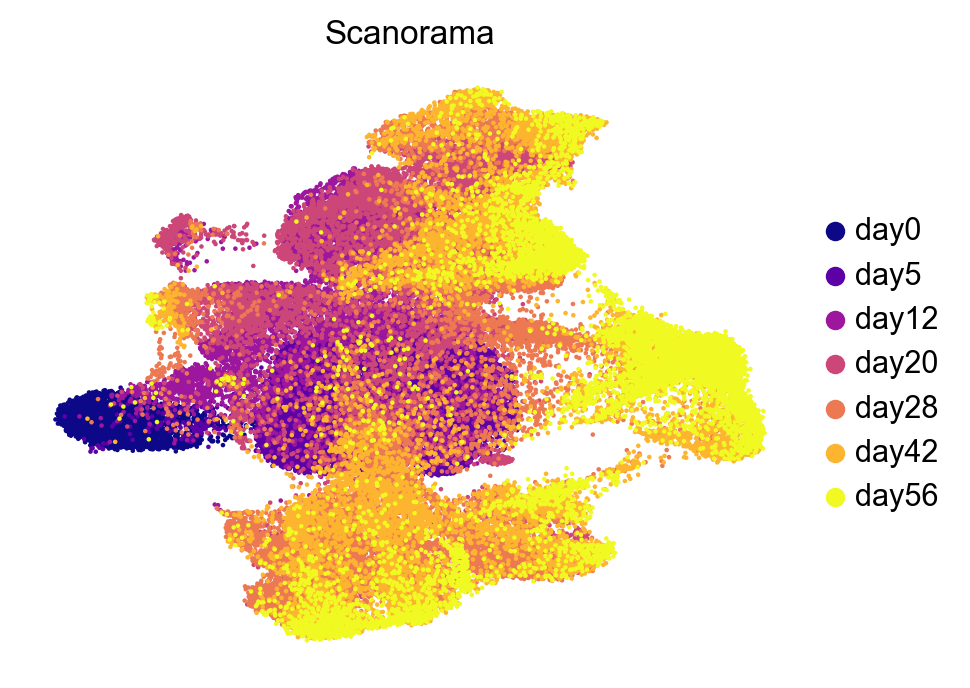

In [68]:
import scvelo as scv

# Backup original UMAP
adata.obsm["_X_umap_backup"] = adata.obsm["X_umap"].copy()

# Use Scanorama UMAP for plotting
adata.obsm["X_umap"] = adata.obsm["X_umap_scanorama"]

# Plot using scVelo styling
scv.pl.umap(
    adata,
    color=["Sample"],                 # You can change this to 'batch', 'leiden', etc.
    title="Scanorama",
    legend_loc="right margin",
    palette="plasma",
    wspace=0.1,
    figsize=(5, 4)
)
#color=["leiden"]  # or ["cell_type"]

# Restore original UMAP (optional but recommended)
adata.obsm["X_umap"] = adata.obsm["_X_umap_backup"]
del adata.obsm["_X_umap_backup"]

In [71]:
adata

AnnData object with n_obs × n_vars = 80193 × 3000
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'Unintegrated', 'X_umap_unintegrated', 'Scanorama', 'X_umap_scanorama'
    varm: 'PCs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [70]:
print(adata.obs.columns)

Index(['Sample', 'n_genes', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels',
       'leiden', '_scvi_raw_norm_scaling', 'batch'],
      dtype='object')


In [74]:
bm = Benchmarker(
    adata,
    batch_key="batch",
    label_key="leiden", #using clustering as proxy
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=["Unintegrated", "Scanorama", "X_scVI"], #"LIGER", "Harmony",  "scANVI"],
    n_jobs=6,
)
bm.benchmark()

Metrics:  10%|▍   | 1/10 [01:09<10:25, 69.54s/it, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [01:09<10:25, 69.54s/it, Bio conservation: nmi_ari_cluster_lab
Metrics:  20%|▏| 2/10 [01:14<04:14, 31.80s/it, Bio conservation: nmi_ari_cluster_lab
Embeddings:  33%|████████████                        | 1/3 [02:53<05:47, 173.94s/it]
                                                                                    
Metrics:  10%|▎  | 1/10 [02:01<18:10, 121.15s/it, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [02:01<18:10, 121.15s/it, Bio conservation: nmi_ari_cluster_la
Metrics:  20%|▏| 2/10 [02:10<07:23, 55.39s/it, Bio conservation: nmi_ari_cluster_lab
Embeddings:  67%|████████████████████████            | 2/3 [07:41<04:00, 240.69s/it]
                                                                                    
Metrics:  10%|▍   | 1/10 [00:03<00:30,  3.33s/it, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [00:03<00:30,  3.33s/it, Bio conservation: 

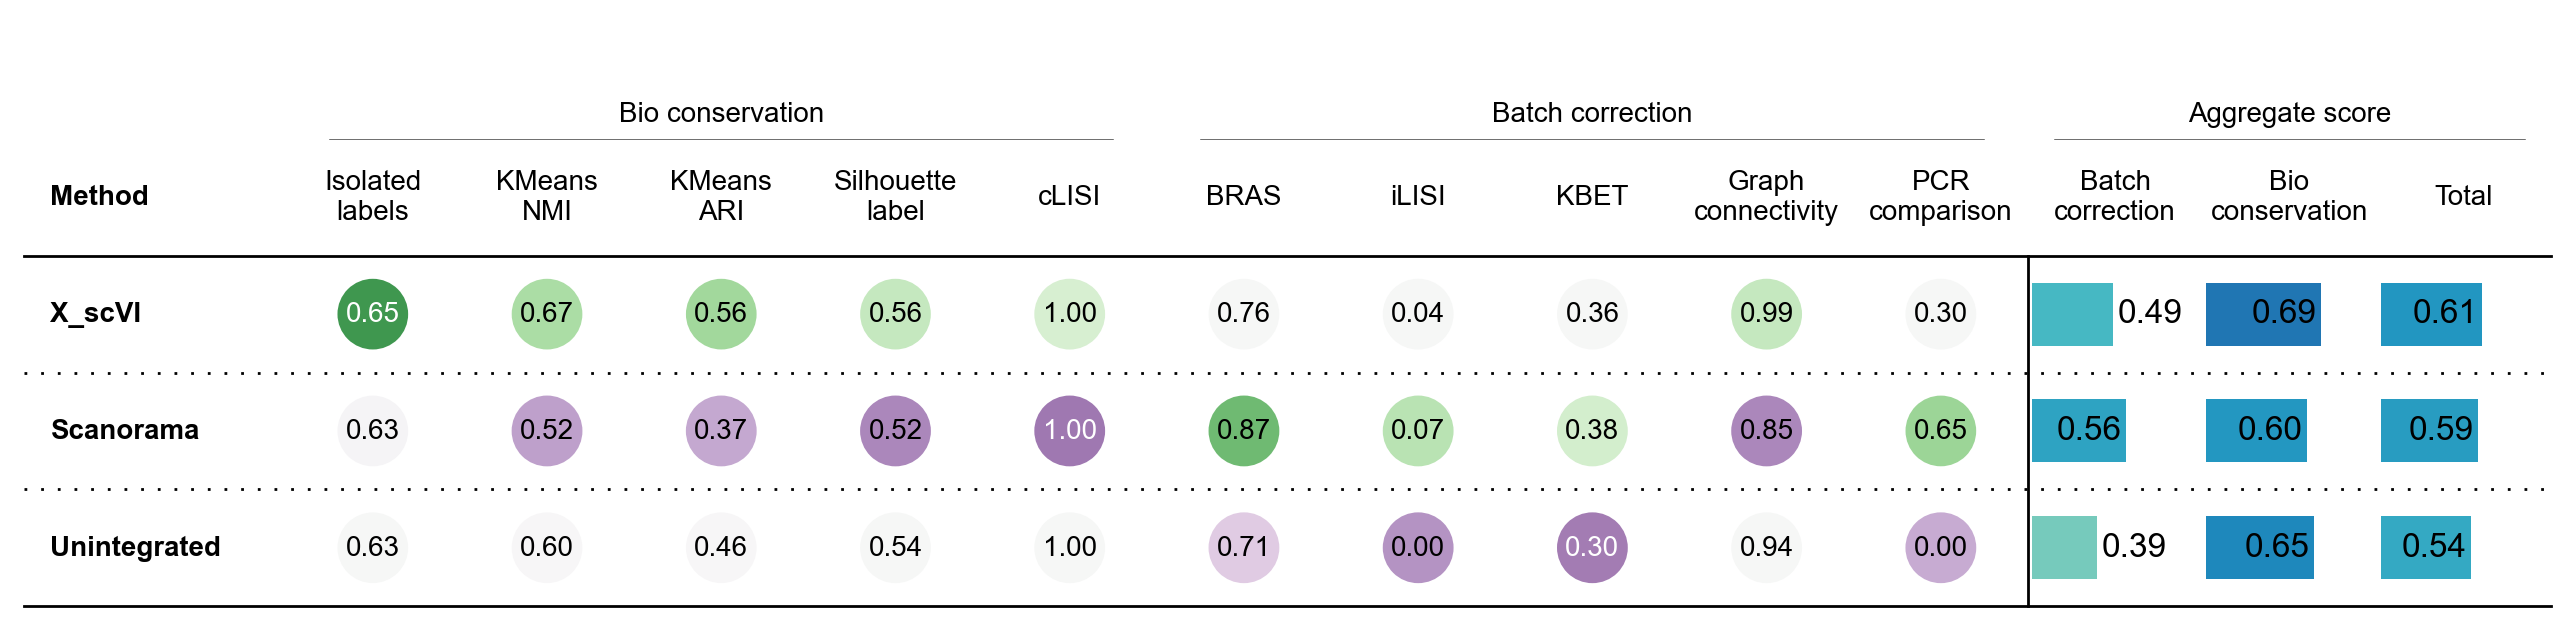

In [76]:
bm.plot_results_table(min_max_scale=False)

In [78]:
# Saving an AnnData object
adata.write("/Users/ogjaime/Desktop/CellRank/integration/Scvi/Benchmarking_integration.h5ad")